<a href="https://colab.research.google.com/github/JaydevDhanji/BluROV2_ROS2/blob/master/Problem_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem D: Prediction of Traffic Flow based on Burgers’ Equation Model

Burgers' equation is a classical PDE model that captures the interplay between nonlinear convection and diffusion, making it well-suited for describing traffic flow dynamics. In this context, the convective term models the tendency for traffic to compress as vehicle density increases, while the diffusive term reflects the smoothing effect of individual driver reactions to surrounding traffic conditions.

The viscous Burgers' equation governing the evolution of vehicle velocity is:

$$
u_t + uu_x = \nu u_{xx}, \qquad x\in(-1,1),\ t\in(0,1] \tag{3}
$$

where:
- $u(x,t)$: vehicle velocity field (m/s),
- $\nu = 0.1/\pi$: kinematic viscosity coefficient (a higher value reflects more cautious, diffusive driver behavior),
- $x$: position along the road segment,
- $t$: time.

Homogeneous Dirichlet boundary conditions are imposed at both ends of the road:

$$
u(-1,\, t) = u(1,\, t) = 0, \qquad t \in (0, 1]
$$

Given an initial velocity profile $u(x, 0) = a(x)$, the full spatio-temporal velocity field $u(x,t)$ for $t > 0$ is uniquely determined by solving Eq. (3). In practice, however, running a high-fidelity finite difference solver for every new initial condition is computationally prohibitive. The goal of this task is therefore to learn a fast surrogate that approximates the solution operator $a(x) \mapsto u(x,t)$.

## Task: predicting the velocity filed $u(x,t)$ given the inital field $a(x)$

A dataset of initial conditions $a(x)$ sampled from a distribution $\mathcal{A}$ has been collected, along with the corresponding velocity fields $u(x,t)$ computed by a high-precision Finite Difference Method (FDM) solver. The dataset is **partially labeled**: only a small subset of initial conditions is paired with its FDM solution, while a much larger set of initial conditions has no corresponding solution available. This reflects a realistic scenario in which high-fidelity simulation data is scarce and expensive to obtain. The trained surrogate model should accurately predict $u(x,t)$ for any new initial condition $a(x)$ drawn from the same distribution $\mathcal{A}$, at negligible computational cost.

### Goals

- Select a suitable deep learning method for this task and justify your choice.
- Report your implementation setup, including network architecture, activation function, optimizer (with learning rate), number of epochs, batch size, loss formulation, and any additional techniques used for improvement.
- Compute the $L^2$ relative error on the **test dataset** at each training epoch and plot the `Error vs. Epoch` curve (reporting the final error). The error is defined as:

$$
\text{error} = \frac{1}{N}\sum_{j=1}^{N}\sqrt{\frac{\displaystyle\sum_i\left|u^{(j)}_{\text{pred}}(x_i,t_i)-u^{(j)}_{\text{true}}(x_i,t_i)\right|^2}{\displaystyle\sum_i\left|u^{(j)}_{\text{true}}(x_i,t_i)\right|^2}}
$$

where $j$ indexes the sample and $i$ indexes the spatio-temporal grid point.

- For the **first test instance**, use `matplotlib` to produce four separate figures:
  1. The initial condition $a(x) = u(x, 0)$
  2. The predicted velocity field $u_{\text{pred}}(x,t)$
  3. The ground truth velocity field $u_{\text{true}}(x,t)$
  4. The pointwise absolute error $|u_{\text{pred}} - u_{\text{true}}|$

### Dataset

All data are provided in `ProblemD_dataset.h5`:

| Key | Shape | Description |
|---|---|---|
| `a_train_labeled` | (200, 256) | $N=200$ **labeled** initial fields, sampled at 256 spatial sensors |
| `u_train_labeled` | (200, 200, 256) | Corresponding FDM-computed velocity fields on a $200\times256$ spatio-temporal grid |
| `a_train_unlabeled` | (1800, 256) | $N=1800$ **unlabeled** initial fields (no paired solution available) |
| `a_test` | (200, 256) | Test initial conditions (**do not use for training**) |
| `u_test` | (200, 200, 256) | Ground truth velocity fields for test instances (**do not use for training**) |
| `x_mesh` | (256, 1) | Spatial coordinates of the 256 grid points |
| `t_mesh` | (200, 1) | Temporal coordinates of the 200 time steps |

> 📥 Dataset download: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/content/drive/MyDrive/DeepLearningforPDEs/ProblemD_dataset.h5
cuda
<KeysViewHDF5 ['a_test', 'a_train_labeled', 'a_train_unlabeled', 't_mesh', 'u_test', 'u_train_labeled', 'x_mesh']>
t_mesh: torch.Size([200, 1]) x_mesh: torch.Size([256, 1])
a_train_labeled: torch.Size([200, 256]) u_train_labeled: torch.Size([200, 200, 256])
a_train_unlabeled: torch.Size([1800, 256])
a_test: torch.Size([200, 256]) u_test: torch.Size([200, 200, 256])


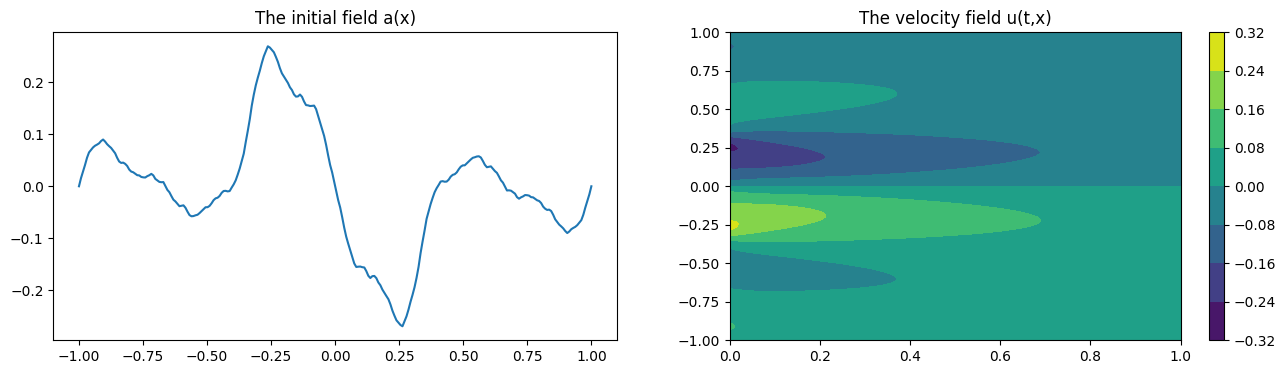

In [ ]:
import os, random, time , math
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
dtype = torch.float32

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if "ProblemD" in file:
            print(os.path.join(root,file))

dataset = '/content/drive/MyDrive/DeepLearningforPDEs/ProblemD_dataset.h5'

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
######################################
# Load training data
######################################
with h5py.File(dataset, 'r') as file:
    print(file.keys())
    t_mesh = torch.tensor(np.array(file['t_mesh']), dtype=dtype)
    x_mesh = torch.tensor(np.array(file['x_mesh']), dtype=dtype)
    a_test = torch.tensor(np.array(file['a_test']), dtype=dtype)
    u_test = torch.tensor(np.array(file['u_test']), dtype=dtype)
    a_train_labeled = torch.tensor(np.array(file['a_train_labeled']), dtype=dtype)
    u_train_labeled = torch.tensor(np.array(file['u_train_labeled']), dtype=dtype)
    a_train_unlabeled = torch.tensor(np.array(file['a_train_unlabeled']), dtype=dtype)
    #
    X, T = np.meshgrid(x_mesh, t_mesh)
#
print('t_mesh:', t_mesh.shape, 'x_mesh:', x_mesh.shape)
print('a_train_labeled:', a_train_labeled.shape, 'u_train_labeled:', u_train_labeled.shape)
print('a_train_unlabeled:', a_train_unlabeled.shape)
print('a_test:', a_test.shape, 'u_test:', u_test.shape)
#################################
inx = 0
fig, axes = plt.subplots(1,2, figsize=(16,4))
#
cntr = axes[0].plot(x_mesh, a_train_labeled[0])
axes[0].set_title('The initial field a(x)')
#
cntr = axes[1].contourf(T, X, u_train_labeled[inx])
axes[1].set_title('The velocity field u(t,x)')
plt.colorbar(cntr)
#
plt.show()

In [ ]:
# Normalization for branch input and output
a_mean, a_std = a_train_labeled.mean(), a_train_labeled.std() + 1e-8
u_mean, u_std = u_train_labeled.mean(), u_train_labeled.std() + 1e-8

print('a mean/std:', a_mean, a_std)
print('u mean/std:', u_mean, u_std)

def normalize_a(a):
    return (a - a_mean) / a_std

def normalize_u(u):
    return (u - u_mean) / u_std

def denormalize_u(u_norm):
    return u_norm * u_std + u_mean


a mean/std: tensor(2.3283e-11) tensor(0.1722)
u mean/std: tensor(-3.1665e-12) tensor(0.1284)


In [ ]:
x_torch = torch.tensor(x_mesh, dtype=torch.float32, device=device).squeeze()
t_torch = torch.tensor(t_mesh, dtype=torch.float32, device=device).squeeze()

A_lab = torch.tensor(normalize_a(a_train_labeled), dtype=torch.float32, device=device)
U_lab = torch.tensor(normalize_u(u_train_labeled), dtype=torch.float32, device=device)
A_unlab = torch.tensor(normalize_a(a_train_unlabeled), dtype=torch.float32, device=device)
A_test = torch.tensor(normalize_a(a_test), dtype=torch.float32, device=device)
U_test = torch.tensor(u_test, dtype=torch.float32, device=device)  # unnormalized for metric

NU = 0.1 / math.pi
print('Viscosity nu =', NU)


Viscosity nu = 0.03183098861837907


/tmp/ipykernel_780/1559558363.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_torch = torch.tensor(x_mesh, dtype=torch.float32, device=device).squeeze()
/tmp/ipykernel_780/1559558363.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_torch = torch.tensor(t_mesh, dtype=torch.float32, device=device).squeeze()
/tmp/ipykernel_780/1559558363.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  A_lab = torch.tensor(normalize_a(a_train_labeled), dtype=torch.float32, device=device)
/tmp/ipykernel_780/1559558363.py:6: UserWarning: To copy 

In [ ]:
class FourierFeatures(nn.Module):
    """
    Converts coordinates (x, t) into Fourier features:

        [x, t, sin(2π(x,t)B), cos(2π(x,t)B)]

    B is generated once and remains fixed during training.
    """

    def __init__(
        self,
        input_dim=2,
        num_frequencies=32,
        scale=2.0,
        include_original=True
    ):
        super().__init__()

        self.include_original = include_original

        # Fixed random frequency matrix.
        B = torch.randn(input_dim, num_frequencies) * scale
        self.register_buffer("B", B)

    def forward(self, x):
        projection = 2.0 * torch.pi * (x @ self.B)

        fourier_features = torch.cat(
            [
                torch.sin(projection),
                torch.cos(projection)
            ],
            dim=-1
        )

        if self.include_original:
            fourier_features = torch.cat(
                [x, fourier_features],
                dim=-1
            )

        return fourier_features

In [ ]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=128, depth=4, activation=nn.Tanh):
        super().__init__()
        layers = []
        layers.append(nn.Linear(in_dim, hidden))
        layers.append(activation())
        for _ in range(depth - 1):
            layers.append(nn.Linear(hidden, hidden))
            layers.append(activation())
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

class PhysicsInformedDeepONet(nn.Module):
    def __init__(self, n_sensors=256, latent_dim=256, branch_hidden=512, trunk_hidden=512, num_frequencies = 32, scale = 2.0):
        super().__init__()
        self.branch = MLP(n_sensors, latent_dim, hidden=branch_hidden, depth=6, activation=nn.GELU)
        self.fourier = FourierFeatures(input_dim=2, num_frequencies=num_frequencies, scale=scale, include_original=True)
        trunk_input_dim = 2 + 2 * num_frequencies
        self.trunk = MLP(trunk_input_dim, latent_dim, hidden=trunk_hidden, depth=6, activation=nn.GELU)
        self.bias = nn.Parameter(torch.zeros(1))

    def encode_cooridnates(self, xt):
      return self.fourier(xt)

    def forward_pairs(self, a, xt):
        b = self.branch(a)
        xt = self.encode_cooridnates(xt)
        tr = self.trunk(xt)
        return torch.sum(b * tr, dim=-1, keepdim=True) + self.bias

    def forward_grid(self, a, xt_grid, chunk=65536):
        b = self.branch(a)
        outs = []
        for i in range(0, xt_grid.shape[0], chunk):
            xt_chunk =xt_grid[i:i+chunk]
            xt = self.encode_cooridnates(xt_chunk)
            tr = self.trunk(xt)
            out = torch.einsum('bp,mp->bm', b, tr) + self.bias
            outs.append(out)
        return torch.cat(outs, dim=1)

model = PhysicsInformedDeepONet(n_sensors=256, latent_dim=128, branch_hidden=256, trunk_hidden=256, num_frequencies=32, scale=2.0).to(device)
print(model)
print('Number of parameters:', sum(p.numel() for p in model.parameters()))


PhysicsInformedDeepONet(
  (branch): MLP(
    (net): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): GELU(approximate='none')
      (4): Linear(in_features=256, out_features=256, bias=True)
      (5): GELU(approximate='none')
      (6): Linear(in_features=256, out_features=256, bias=True)
      (7): GELU(approximate='none')
      (8): Linear(in_features=256, out_features=256, bias=True)
      (9): GELU(approximate='none')
      (10): Linear(in_features=256, out_features=256, bias=True)
      (11): GELU(approximate='none')
      (12): Linear(in_features=256, out_features=128, bias=True)
    )
  )
  (fourier): FourierFeatures()
  (trunk): MLP(
    (net): Sequential(
      (0): Linear(in_features=66, out_features=256, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): GELU(approxima

In [ ]:
test_a = torch.randn(4, 256).to(device)
test_xt = torch.randn(4, 2).to(device)

test_pred = model.forward_pairs(test_a, test_xt)

print("Pair prediction shape:", test_pred.shape)

Pair prediction shape: torch.Size([4, 1])


In [ ]:
test_grid = torch.randn(100, 2).to(device)

test_pred_grid = model.forward_grid(
    test_a[:1],
    test_grid
)

print("Grid prediction shape:", test_pred_grid.shape)

Grid prediction shape: torch.Size([1, 100])


In [ ]:
def sample_supervised(batch_size=4096):
    ns = A_lab.shape[0]
    nt = t_torch.numel()
    nx = x_torch.numel()
    j = torch.randint(0, ns, (batch_size,), device= device)
    it = torch.randint(0, nt, (batch_size,), device=device)
    ix = torch.randint(0, nx, (batch_size,), device=device)
    a = A_lab[j]
    x_col = x_torch[ix]
    t_col = t_torch[it]
    xt = torch.stack([x_col, t_col], dim=1)
    target = U_lab[j, it, ix].unsqueeze(1)
    return a, xt, target

def sample_initial(batch_size=2048, use_unlabeled=True):
    # Sample points on t=0 and enforce u(x,0)=a(x).
    A_pool = torch.cat([A_lab, A_unlab], dim=0) if use_unlabeled else A_lab
    ns = A_pool.shape[0]
    nx = x_torch.shape[0]
    j = torch.randint(0, ns, (batch_size,), device= device)
    ix = torch.randint(0, nx, (batch_size,), device=device)
    a = A_pool[j]
    x_sample = x_torch[ix]
    t_sample = torch.zeros_like(x_sample)
    xt = torch.stack([x_sample, t_sample], dim=1)
    row = torch.arange(batch_size, device=device)
    a_phys = a * a_std + a_mean
    target = ((a_phys[row, ix] - u_mean) / u_std).unsqueeze(1)

    target = a[row, ix].unsqueeze(1)
    return a, xt, target

def sample_boundary(batch_size=2048, use_unlabeled=True):
    # Sample boundary points x=-1 and x=1 where u=0.
    A_pool = torch.cat([A_lab, A_unlab], dim=0) if use_unlabeled else A_lab
    ns = A_pool.shape[0]
    j = torch.randint(0, ns, (batch_size,), device=device)
    t = torch.rand(batch_size, device=device)
    side = torch.randint(0, 2, (batch_size,), device=device).float()
    x = torch.where(side > 0.5, torch.ones_like(t), -torch.ones_like(t))
    a = A_pool[j]
    xt = torch.stack([x, t], dim=1)
    target = torch.full((batch_size, 1), (0.0 - u_mean) / u_std, device=device)
    return a, xt, target

def sample_physics(batch_size=2048, use_unlabeled=True):
    # Sample interior collocation points for Burgers residual.
    A_pool = torch.cat([A_lab, A_unlab], dim=0) if use_unlabeled else A_lab
    ns = A_pool.shape[0]
    j = torch.randint(0, ns, (batch_size,), device=device)
    x = -1.0 + 2.0 * torch.rand(batch_size, device=device)
    t = torch.rand(batch_size, device=device)
    a = A_pool[j]
    xt = torch.stack([x, t], dim=1).requires_grad_(True)
    return a, xt


In [ ]:
a_i, xt_i, y_i = sample_initial(2048)

pred_i = model.forward_pairs(a_i, xt_i)

print(pred_i.shape)
print(y_i.shape)

torch.Size([2048, 1])
torch.Size([2048, 1])


In [ ]:
def burgers_residual(model, a, xt):
    # Compute residual u_t + u u_x - nu u_xx in physical u-scale.
    u_norm = model.forward_pairs(a, xt)
    u = u_norm * u_std + u_mean

    grad_u = torch.autograd.grad(u, xt, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]
    grad_ux = torch.autograd.grad(u_x, xt, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_xx = grad_ux[:, 0:1]
    return u_t + u * u_x - NU * u_xx

@torch.no_grad()
def relative_l2_error(model, max_test=None, batch_samples=10):
    model.eval()
    ntest = A_test.shape[0] if max_test is None else min(max_test, A_test.shape[0])
    X, T = torch.meshgrid(x_torch, t_torch, indexing='xy')
    xt_grid = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)
    rels = []
    for s in range(0, ntest, batch_samples):
        a = A_test[s:s+batch_samples]
        pred_norm = model.forward_grid(a, xt_grid)
        pred = denormalize_u(pred_norm).reshape(a.shape[0], len(t_mesh), len(x_mesh))
        true = U_test[s:s+batch_samples]
        num = torch.sum((pred - true)**2, dim=(1,2))
        den = torch.sum(true**2, dim=(1,2)) + 1e-12
        rels.append(torch.sqrt(num / den))
    return torch.cat(rels).mean().item()


In [ ]:
epochs = 5000
lr = 3e-4

w_sup = 10
w_pde = 1
w_ic = 50
w_bc = 10

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min", factor = 0.5, patience=200, min_lr=1e-6)

history = {'epoch': [], 'loss': [], 'sup': [], 'pde': [], 'ic': [], 'bc': [], 'test_l2': []}

eval_every = 100
quick_eval_test_samples = None

start = time.time()
for ep in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    a_s, xt_s, y_s = sample_supervised(batch_size=4096)
    pred_s = model.forward_pairs(a_s, xt_s)
    loss_sup = F.mse_loss(pred_s, y_s)

    a_i, xt_i, y_i = sample_initial(batch_size=2048, use_unlabeled=True)
    pred_i = model.forward_pairs(a_i, xt_i)
    loss_ic = F.mse_loss(pred_i, y_i)

    a_b, xt_b, y_b = sample_boundary(batch_size=2048, use_unlabeled=True)
    pred_b = model.forward_pairs(a_b, xt_b)
    loss_bc = F.mse_loss(pred_b, y_b)

    a_p, xt_p = sample_physics(batch_size=8192, use_unlabeled=True)
    res = burgers_residual(model, a_p, xt_p)
    loss_pde = torch.mean(res**2)

    loss = w_sup*loss_sup + w_pde*loss_pde + w_ic*loss_ic + w_bc*loss_bc
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step(err)

    if ep % eval_every == 0 or ep == 1:
        err = relative_l2_error(model, max_test=quick_eval_test_samples, batch_samples=10)
        history['epoch'].append(ep)
        history['loss'].append(loss.item())
        history['sup'].append(loss_sup.item())
        history['pde'].append(loss_pde.item())
        history['ic'].append(loss_ic.item())
        history['bc'].append(loss_bc.item())
        history['test_l2'].append(err)
        print(f"Epoch {ep:5d} | loss {loss.item():.6e} | sup {loss_sup.item():.6e} | pde {loss_pde.item():.6e} | ic {loss_ic.item():.3e} | bc {loss_bc.item():.3e} | relL2 {err:.4f}")

print('Training time [s]:', time.time() - start)
final_error = relative_l2_error(model, max_test=None, batch_samples=10)
print('Final full test relative L2 error:', final_error)


Epoch     1 | loss 2.388978e-01 | sup 3.158920e-03 | pde 2.206240e-02 | ic 3.693e-03 | bc 6.023e-05 | relL2 0.2132
Epoch   100 | loss 2.386528e-01 | sup 3.430366e-03 | pde 2.226758e-02 | ic 3.631e-03 | bc 5.491e-05 | relL2 0.0765
Epoch   200 | loss 2.206302e-01 | sup 3.465845e-03 | pde 1.988339e-02 | ic 3.315e-03 | bc 3.524e-05 | relL2 0.0715
Epoch   300 | loss 2.137010e-01 | sup 3.541220e-03 | pde 1.827483e-02 | ic 3.191e-03 | bc 4.840e-05 | relL2 0.0708
Epoch   400 | loss 2.226386e-01 | sup 2.619700e-03 | pde 1.938429e-02 | ic 3.523e-03 | bc 8.994e-05 | relL2 0.0761
Epoch   500 | loss 2.455421e-01 | sup 4.245111e-03 | pde 1.893886e-02 | ic 3.658e-03 | bc 1.271e-04 | relL2 0.0703
Epoch   600 | loss 2.279160e-01 | sup 3.725545e-03 | pde 2.109335e-02 | ic 3.380e-03 | bc 5.835e-05 | relL2 0.0783
Epoch   700 | loss 2.240835e-01 | sup 3.855891e-03 | pde 1.928535e-02 | ic 3.314e-03 | bc 5.146e-05 | relL2 0.0796
Epoch   800 | loss 1.869238e-01 | sup 3.196271e-03 | pde 1.997754e-02 | ic 2.691

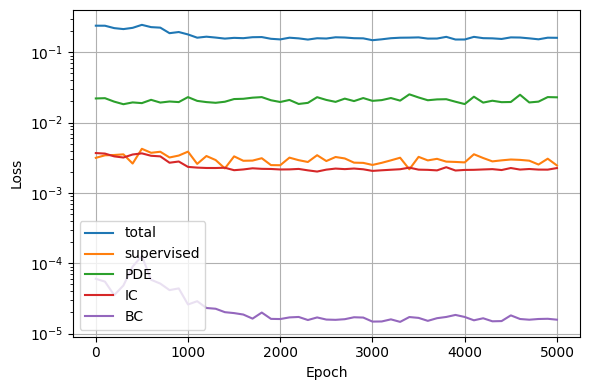

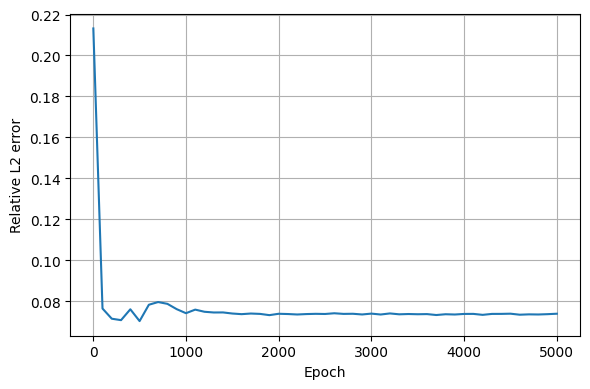

In [ ]:
plt.figure(figsize=(6,4))
plt.semilogy(history['epoch'], history['loss'], label='total')
plt.semilogy(history['epoch'], history['sup'], label='supervised')
plt.semilogy(history['epoch'], history['pde'], label='PDE')
plt.semilogy(history['epoch'], history['ic'], label='IC')
plt.semilogy(history['epoch'], history['bc'], label='BC')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history['epoch'], history['test_l2'])
plt.xlabel('Epoch')
plt.ylabel('Relative L2 error')
plt.grid(True)
plt.tight_layout()
plt.show()

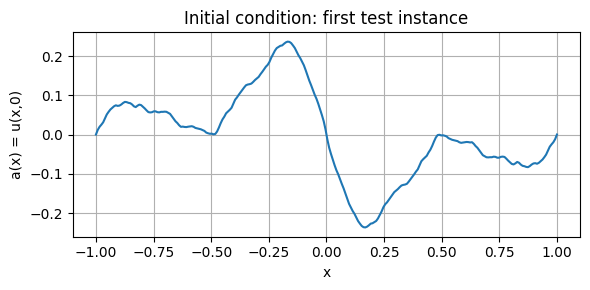

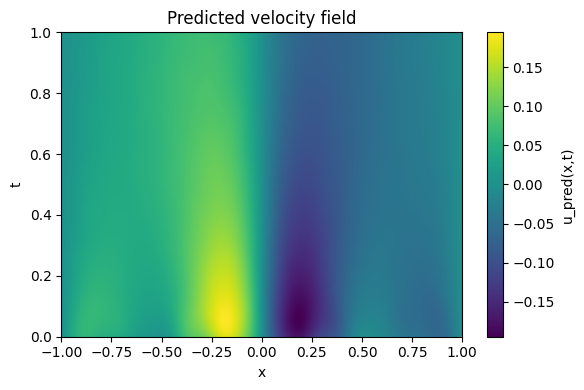

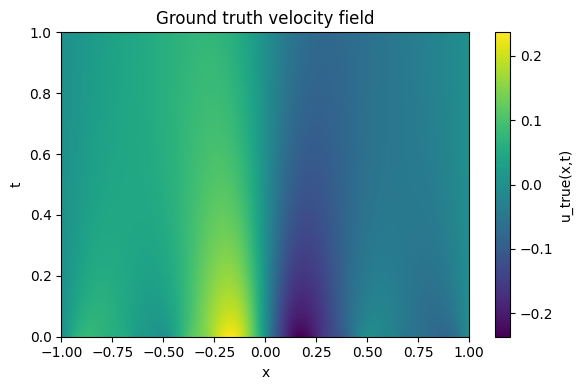

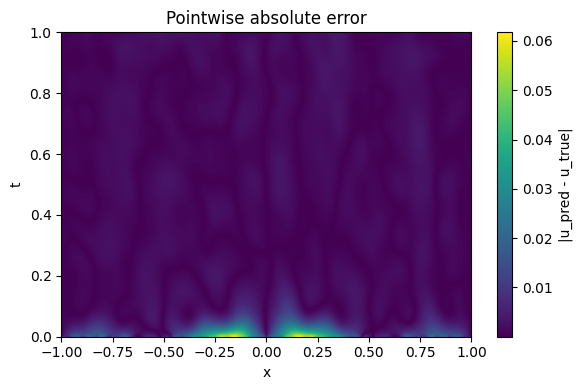

First test instance relative L2 error: 0.06285785


In [ ]:
@torch.no_grad()
def predict_one(index=0):
    model.eval()
    X, T = torch.meshgrid(x_torch, t_torch, indexing='xy')
    xt_grid = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)
    pred_norm = model.forward_grid(A_test[index:index+1], xt_grid)
    pred = denormalize_u(pred_norm).reshape(len(t_mesh), len(x_mesh)).detach().cpu().numpy()
    return pred

idx = 0
u_pred = predict_one(idx)
u_true = u_test[idx].detach().cpu().numpy()
a0 = a_test[idx].detach().cpu().numpy()
abs_err = np.abs(u_pred - u_true)

extent = [x_mesh.min(), x_mesh.max(), t_mesh.min(), t_mesh.max()]

plt.figure(figsize=(6,3))
plt.plot(x_mesh, a0)
plt.xlabel('x')
plt.ylabel('a(x) = u(x,0)')
plt.title('Initial condition: first test instance')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.imshow(u_pred, origin='lower', aspect='auto', extent=extent)
plt.colorbar(label='u_pred(x,t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predicted velocity field')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.imshow(u_true, origin='lower', aspect='auto', extent=extent)
plt.colorbar(label='u_true(x,t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Ground truth velocity field')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.imshow(abs_err, origin='lower', aspect='auto', extent=extent)
plt.colorbar(label='|u_pred - u_true|')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Pointwise absolute error')
plt.tight_layout()
plt.show()

rel0 = np.sqrt(np.sum((u_pred-u_true)**2) / (np.sum(u_true**2) + 1e-12))
print('First test instance relative L2 error:', rel0)


In [ ]:
X, T = torch.meshgrid(
    x_torch,
    t_torch,
    indexing="xy"
)

xt_grid = torch.stack(
    [
        X.reshape(-1),
        T.reshape(-1)
    ],
    dim=1
)

In [ ]:
model.eval()

all_errors = []

with torch.no_grad():

    for i in range(A_test.shape[0]):

        a0 = A_test[i:i+1].to(device)

        pred_norm = model.forward_grid(
            a0,
            xt_grid
        )

        pred = denormalize_u(pred_norm)

        pred = pred.reshape(
            len(t_mesh),
            len(x_mesh)
        )

        true = U_test[i].to(device)

        err = torch.linalg.norm(pred - true) / (
            torch.linalg.norm(true) + 1e-12
        )

        all_errors.append(err.item())

print("Mean relative L2:", np.mean(all_errors))
print("Std:", np.std(all_errors))
print("Best:", np.min(all_errors))
print("Worst:", np.max(all_errors))

Mean relative L2: 0.07394147472456097
Std: 0.022644570138974716
Best: 0.04957905784249306
Worst: 0.18290135264396667
